In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def importeer_schone_data(bestandsnaam, kolommen_lijst):
    """
    Leest het databestand in, skipt de metadata en geeft de kolommen namen.
    """
    # sep='\s+' herkent één of meerdere spaties als scheidingsteken
    # skiprows=5 slaat de eerste 5 regels uit het .txt bestand over
    # header=None zorgt ervoor dat de eerste datarij (rij 6) niet als titel wordt gebruikt
    df = pd.read_csv(bestandsnaam, sep='\s+', skiprows=5, header=None)
    
    # Omdat we de originele titels hebben geskipt, geven we ze hier handmatig weer terug
    # Gebaseerd op regel 3, 4 en 5 uit jouw afbeelding:
    geselecteerde_df = df.iloc[:, kolommen_lijst]
    df.columns = ['Time_s', 'element_1_m', 'element_2_m', 'element_3_m', 'element_5_m', 'element_6_m']
    
    return geselecteerde_df, df.columns

#importeer_schone_data(r"Data\SWL-2%-CS1-Test-2\2026-3-4 SWL Berm 2% - Test 2.experiment - 150% (4).txt", [0])


<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
C:\Users\929952\AppData\Local\Temp\ipykernel_24264\783546372.py:13: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(bestandsnaam, sep='\s+', skiprows=5, header=None)


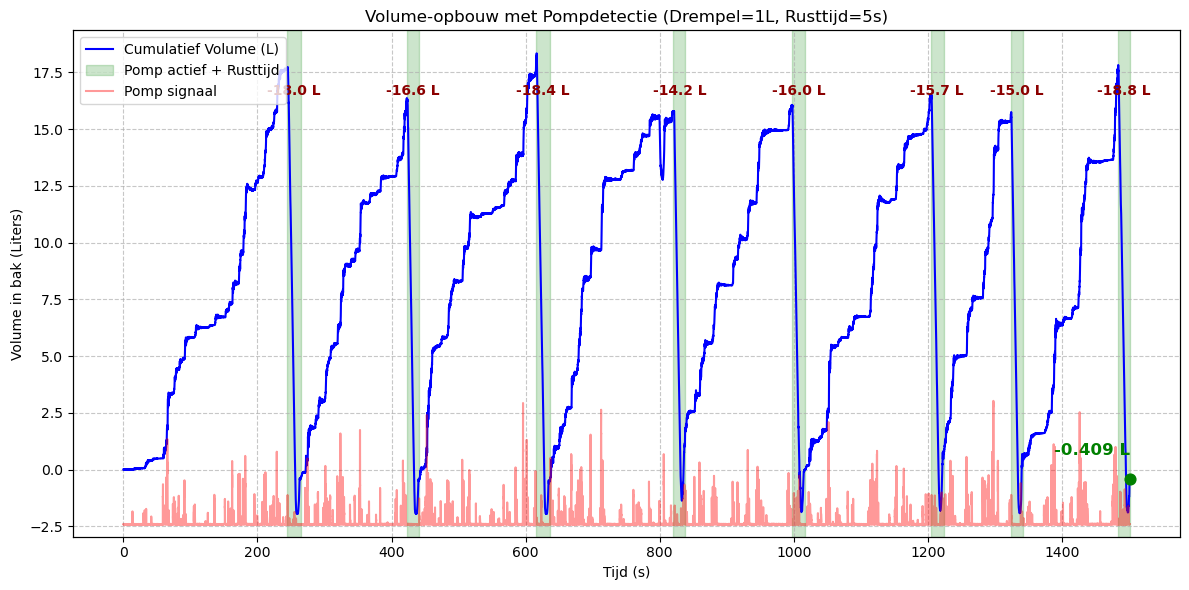

--> Functie gereed. Er zijn 8 pompmomenten gedetecteerd (>1L).
--> Totaal overgeslagen volume (met pompcorrectie van +132.6L): 132.19 Liter


In [356]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def bereken_bak_volume_pomp(data, T_golf, pomp_drempel_L, rusttijd_s):
    """
    Berekent het stapsgewijze volume in een bak, detecteert pompmomenten
    en plot tegelijkertijd een indicatief signaal (data[4]) aan de onderkant.
    Inclusief weergave van de eindstand in de grafiek.
    """
    # --- Vaste parameters ---
    fs = 128           # [Hz] Vaste sampling rate
    lengte_bak = 0.365  # [m]
    breedte_bak = 0.268 # [m]
    
    oppervlakte_pomp = lengte_bak * breedte_bak * 0.18
    oppervlakte = lengte_bak * breedte_bak - oppervlakte_pomp

    # --- 1. Data inlezen (inclusief het signaal!) ---
    df = pd.DataFrame({
        'Tijd': data[0],
        'Waterstand': data[5],
        'Signaal': data[4]  
    })
    
    # --- 2. Smoothing (1/4 golfperiode) ---
    window_size = int(0.25 * T_golf * fs)
    df['Waterstand_smooth'] = df['Waterstand'].rolling(window=window_size, center=True).mean().bfill().ffill()
    
    # --- 3. Volume Berekening ---
    df['Volume_L'] = (df['Waterstand_smooth'] - df['Waterstand_smooth'].iloc[0]) * oppervlakte * 1000 
    
    # --- 4. POMP DETECTIE ---
    window_pomp = int(1.5 * T_golf * fs)
    df['Volume_pomp_smooth'] = df['Volume_L'].rolling(window_pomp, center=True).mean().bfill().ffill()
    
    df['dV'] = df['Volume_pomp_smooth'].diff(fs).fillna(0)
    
    is_dropping = df['dV'] < -0.5 
    df['pump_group'] = (~is_dropping).cumsum()
    
    pump_events = []
    totale_pomp_correctie = 0
    
    for name, group in df[is_dropping].groupby('pump_group'):
        if len(group) == 0:
            continue
            
        idx_start = group.index[0]
        idx_end = group.index[-1]
        
        zoek_start = max(0, idx_start - 3 * fs)
        real_start_idx = df['Volume_pomp_smooth'].iloc[zoek_start:idx_start+1].idxmax()
        
        zoek_eind = min(len(df) - 1, idx_end + 3 * fs)
        real_end_idx_steep = df['Volume_pomp_smooth'].iloc[idx_end:zoek_eind+1].idxmin()
        
        idx_na_rust = min(len(df) - 1, real_end_idx_steep + int(rusttijd_s * fs))
        
        vol_start = df['Volume_pomp_smooth'].loc[real_start_idx]
        vol_na_rust = df['Volume_pomp_smooth'].loc[idx_na_rust]
        vol_drop = vol_start - vol_na_rust
        
        if vol_drop >= pomp_drempel_L:
            t_start = df['Tijd'].loc[real_start_idx]
            t_end = df['Tijd'].loc[idx_na_rust] 
            
            if pump_events and real_start_idx <= pump_events[-1]['end_idx']:
                 pump_events[-1]['end_idx'] = max(pump_events[-1]['end_idx'], idx_na_rust)
                 pump_events[-1]['t_end'] = df['Tijd'].loc[pump_events[-1]['end_idx']]
                 pump_events[-1]['drop'] = df['Volume_pomp_smooth'].loc[pump_events[-1]['start_idx']] - df['Volume_pomp_smooth'].loc[pump_events[-1]['end_idx']]
            else:
                pump_events.append({
                    'start_idx': real_start_idx,
                    'end_idx': idx_na_rust,
                    't_start': t_start,
                    't_end': t_end,
                    'drop': vol_drop
                })

    totale_pomp_correctie = sum(ev['drop'] for ev in pump_events)
    totaal_volume = df['Volume_L'].iloc[-1] + totale_pomp_correctie

    # --- 5. Visualisatie ---
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Plot het volume op de linkeras (ax1)
    ax1.plot(df['Tijd'], df['Volume_L'], label='Cumulatief Volume (L)', color='blue')
    
    # --- NIEUW: Eindwaarde markeren in de plot met GROENE letters ---
    laatste_tijd = df['Tijd'].iloc[-1]
    laatste_volume = df['Volume_L'].iloc[-1]
    
    ax1.scatter(laatste_tijd, laatste_volume, color='green', s=60, zorder=5)
    
    y_offset = df['Volume_L'].max() * 0.05
    ax1.text(laatste_tijd, laatste_volume + y_offset, f"{laatste_volume:.3f} L", 
             color='green', ha='right', va='bottom', fontweight='bold', fontsize=12)
    # ----------------------------------------------------------------
    
    # Kleur de pompmomenten in
    for i, event in enumerate(pump_events):
        label = 'Pomp actief + Rusttijd' if i == 0 else "" 
        ax1.axvspan(event['t_start'], event['t_end'], color='green', alpha=0.2, label=label)
        
        mid_t = (event['t_start'] + event['t_end']) / 2
        y_pos = df['Volume_L'].max() * 0.9
        ax1.text(mid_t, y_pos, f"-{event['drop']:.1f} L", color='darkred', ha='center', fontweight='bold')
    
    ax1.set_xlabel('Tijd (s)')
    ax1.set_ylabel('Volume in bak (Liters)')
    ax1.grid(True, linestyle='--', alpha=0.7)

    # --- EXTRA SIGNAAL PLOTTEN (Rechteras) ---
    ax2 = ax1.twinx()  # Tweede as aanmaken
    ax2.plot(df['Tijd'], df['Signaal'], color="red", alpha=0.4, label='Pomp signaal')
    
    # Haal de getallen weg zodat het puur een indicatie is
    ax2.set_yticks([])
    
    # Push het signaal naar de bodem door de as bovenaan heeeel lang te maken
    sig_min = df['Signaal'].min()
    sig_max = df['Signaal'].max()
    sig_range = sig_max - sig_min if sig_max != sig_min else 1
    ax2.set_ylim(sig_min - 0.1 * sig_range, sig_max + 3 * sig_range)

    # Legenda's samenvoegen
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

    plt.title(f'Volume-opbouw met Pompdetectie (Drempel={pomp_drempel_L}L, Rusttijd={rusttijd_s}s)')
    plt.tight_layout()
    plt.show()
    
    print(f"--> Functie gereed. Er zijn {len(pump_events)} pompmomenten gedetecteerd (>{pomp_drempel_L}L).")
    print(f"--> Totaal overgeslagen volume (met pompcorrectie van +{totale_pomp_correctie:.1f}L): {totaal_volume:.2f} Liter")
    
    return df, totaal_volume

data,alles = importeer_schone_data(r"Data\Wave gauges data\Emerged-4%-CS4-Test-1\2026-3-19 EM Wide Berm 4% - Test 1.experiment - 150% (4).txt", [0,4,5])

# --- AANROEPEN ---
df_resultaten, totaal = bereken_bak_volume_pomp(data, T_golf=1.5, pomp_drempel_L=1, rusttijd_s=5)


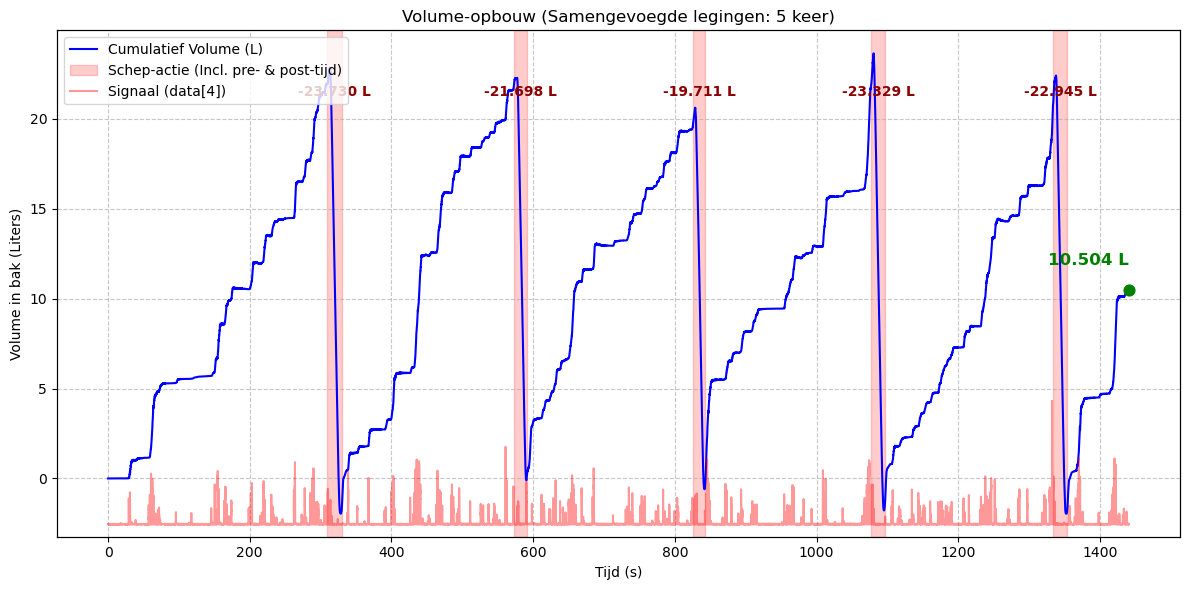

--> TOTAAL AANTAL SAMENGEVOEGDE LEGINGEN: 5
--> TOTAAL OVERGESLAGEN VOLUME (Incl scheppen): 121.918 Liter


In [353]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def bereken_bak_volume_handmatig(data, T_golf, pomp_drempel_L, rusttijd_s, samenvoeg_tijd_s, voortijd_s=3.0):
    """
    Berekent het stapsgewijze volume, detecteert handmatige leegloop,
    voegt extracties binnen 'samenvoeg_tijd_s' samen tot één actie,
    en wacht pas op het einde 'rusttijd_s' seconden om het werkelijke
    weggehaalde volume af te lezen. 
    """
    # --- Vaste parameters ---
    fs = 128           
    lengte_bak = 0.365  
    breedte_bak = 0.268 
    
    # GEEN pomp, dus de volledige oppervlakte wordt gebruikt!
    oppervlakte = lengte_bak * breedte_bak

    # --- 1. Data inlezen ---
    df = pd.DataFrame({
        'Tijd': data[0],
        'Waterstand': data[5],
        'Signaal': data[4]  
    })
    
    # --- 2. Smoothing ---
    window_size = int(1 * T_golf * fs)
    df['Waterstand_smooth'] = df['Waterstand'].rolling(window=window_size, center=True).mean().bfill().ffill()
    
    # --- NIEUW: FIX VOOR HET NUL-PUNT ---
    # We nemen het gemiddelde van de eerste 3 seconden (3 * fs samples) als de stabiele startwaarde
    nul_niveau = df['Waterstand_smooth'].iloc[0:int(3*fs)].mean()
    df['Volume_L'] = (df['Waterstand_smooth'] - nul_niveau) * oppervlakte * 1000 
    
    # --- 3. HANDMATIG LEEGMAKEN DETECTIE ---
    window_pomp = int(1.5 * T_golf * fs)
    df['Volume_pomp_smooth'] = df['Volume_L'].rolling(window=window_pomp, center=True).mean().bfill().ffill()
    
    df['dV'] = df['Volume_pomp_smooth'].diff(fs).fillna(0)
    
    # Zorg dat de drempel gevoelig genoeg is (-0.1 of -0.5, afhankelijk van hoe snel je schepte)
    is_dropping = df['dV'] < -0.1 
    df['pump_group'] = (~is_dropping).cumsum()
    
    ruwe_events = []
    
    # Stap A: Verzamel alle losse, ruwe dalingen
    for name, group in df[is_dropping].groupby('pump_group'):
        if len(group) == 0:
            continue
            
        idx_start = group.index[0]
        idx_end = group.index[-1]
        
        zoek_start = max(0, idx_start - 3 * fs)
        real_start_idx = df['Volume_pomp_smooth'].iloc[zoek_start:idx_start+1].idxmax()
        
        zoek_eind = min(len(df) - 1, idx_end + 3 * fs)
        real_end_idx_steep = df['Volume_pomp_smooth'].iloc[idx_end:zoek_eind+1].idxmin()
        
        ruwe_events.append({
            'start_idx': real_start_idx,
            'end_idx': real_end_idx_steep,
            't_start': df['Tijd'].loc[real_start_idx],
            't_end': df['Tijd'].loc[real_end_idx_steep]
        })

    # Stap B: Voeg dalingen samen die binnen de samenvoeg_tijd (7s) vallen
    gecombineerde_events = []
    
    for ev in ruwe_events:
        if not gecombineerde_events:
            gecombineerde_events.append(ev.copy())
        else:
            vorige_ev = gecombineerde_events[-1]
            tijd_verschil = ev['t_start'] - vorige_ev['t_end']
            
            if tijd_verschil <= samenvoeg_tijd_s:
                vorige_ev['end_idx'] = ev['end_idx']
                vorige_ev['t_end'] = ev['t_end']
            else:
                gecombineerde_events.append(ev.copy())

    # Stap C: Voortijd en Rusttijd toepassen op samengevoegde acties
    pump_events = []
    for ev in gecombineerde_events:
        
        idx_voor_emmer = max(0, ev['start_idx'] - int(voortijd_s * fs))
        idx_na_rust = min(len(df) - 1, ev['end_idx'] + int(rusttijd_s * fs))
        
        vol_start = df['Volume_pomp_smooth'].loc[idx_voor_emmer]
        vol_na_rust = df['Volume_pomp_smooth'].loc[idx_na_rust]
        vol_drop = vol_start - vol_na_rust
        
        if vol_drop >= pomp_drempel_L:
            pump_events.append({
                'start_idx': idx_voor_emmer,
                'end_idx': idx_na_rust, 
                't_start': df['Tijd'].loc[idx_voor_emmer],
                't_end': df['Tijd'].loc[idx_na_rust], 
                'drop': vol_drop
            })

    # Totalen berekenen
    totale_pomp_correctie = sum(ev['drop'] for ev in pump_events)
    aantal_legingen = len(pump_events)
    
    # --- 4. Totaal Volume Berekenen ---
    totaal_volume = df['Volume_L'].iloc[-1] + totale_pomp_correctie

    # --- 5. Visualisatie ---
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    ax1.plot(df['Tijd'], df['Volume_L'], label='Cumulatief Volume (L)', color='blue')
    
    # --- NIEUW: Eindwaarde markeren in de plot met GROENE letters ---
    laatste_tijd = df['Tijd'].iloc[-1]
    laatste_volume = df['Volume_L'].iloc[-1]
    
    ax1.scatter(laatste_tijd, laatste_volume, color='green', s=60, zorder=5)
    
    y_offset = df['Volume_L'].max() * 0.05
    ax1.text(laatste_tijd, laatste_volume + y_offset, f"{laatste_volume:.3f} L", 
             color='green', ha='right', va='bottom', fontweight='bold', fontsize=12)
    # ----------------------------------------------------------------

    for i, event in enumerate(pump_events):
        label = 'Schep-actie (Incl. pre- & post-tijd)' if i == 0 else "" 
        ax1.axvspan(event['t_start'], event['t_end'], color='red', alpha=0.2, label=label)
        
        mid_t = (event['t_start'] + event['t_end']) / 2
        y_pos = df['Volume_L'].max() * 0.9
        ax1.text(mid_t, y_pos, f"-{event['drop']:.3f} L", color='darkred', ha='center', fontweight='bold')
    
    ax1.set_xlabel('Tijd (s)')
    ax1.set_ylabel('Volume in bak (Liters)')
    ax1.grid(True, linestyle='--', alpha=0.7)

    # --- EXTRA SIGNAAL PLOTTEN ---
    ax2 = ax1.twinx() 
    ax2.plot(df['Tijd'], df['Signaal'], color="red", alpha=0.4, label='Signaal (data[4])')
    ax2.set_yticks([])
    
    sig_min = df['Signaal'].min()
    sig_max = df['Signaal'].max()
    sig_range = sig_max - sig_min if sig_max != sig_min else 1
    ax2.set_ylim(sig_min - 0.1 * sig_range, sig_max + 3 * sig_range)

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

    plt.title(f'Volume-opbouw (Samengevoegde legingen: {aantal_legingen} keer)')
    plt.tight_layout()
    plt.show()

    print(f"--> TOTAAL AANTAL SAMENGEVOEGDE LEGINGEN: {aantal_legingen}")
    print(f"--> TOTAAL OVERGESLAGEN VOLUME (Incl scheppen): {totaal_volume:.3f} Liter")
    
    return df, totaal_volume, aantal_legingen

data1,alles = importeer_schone_data(r"Data\Wave gauges data\Emerged-4%-CS4-Test-1\2026-3-19 EM Wide Berm 4% - Test 1.experiment - 130% (4).txt", [0,4,5])

# --- Aanroepen (Nu met de voortijd_s input erbij) ---
df_result, eind_volume, legingen = bereken_bak_volume_handmatig(
    data1, 
    T_golf=1.5, 
    pomp_drempel_L=1.9, 
    rusttijd_s=1, 
    samenvoeg_tijd_s=7,
    voortijd_s=3     # <--- Hier kun je hem zelf aanpassen!
)

--- RESULTATEN TUSSEN SIGNAAL-STARTS ---
Aantal geanalyseerde golf-intervallen: 1218
Maximale toename tussen de voet van golf A en B = 0.22 Liter
Dit gebeurde tussen t = 627.8s en t = 628.8s.



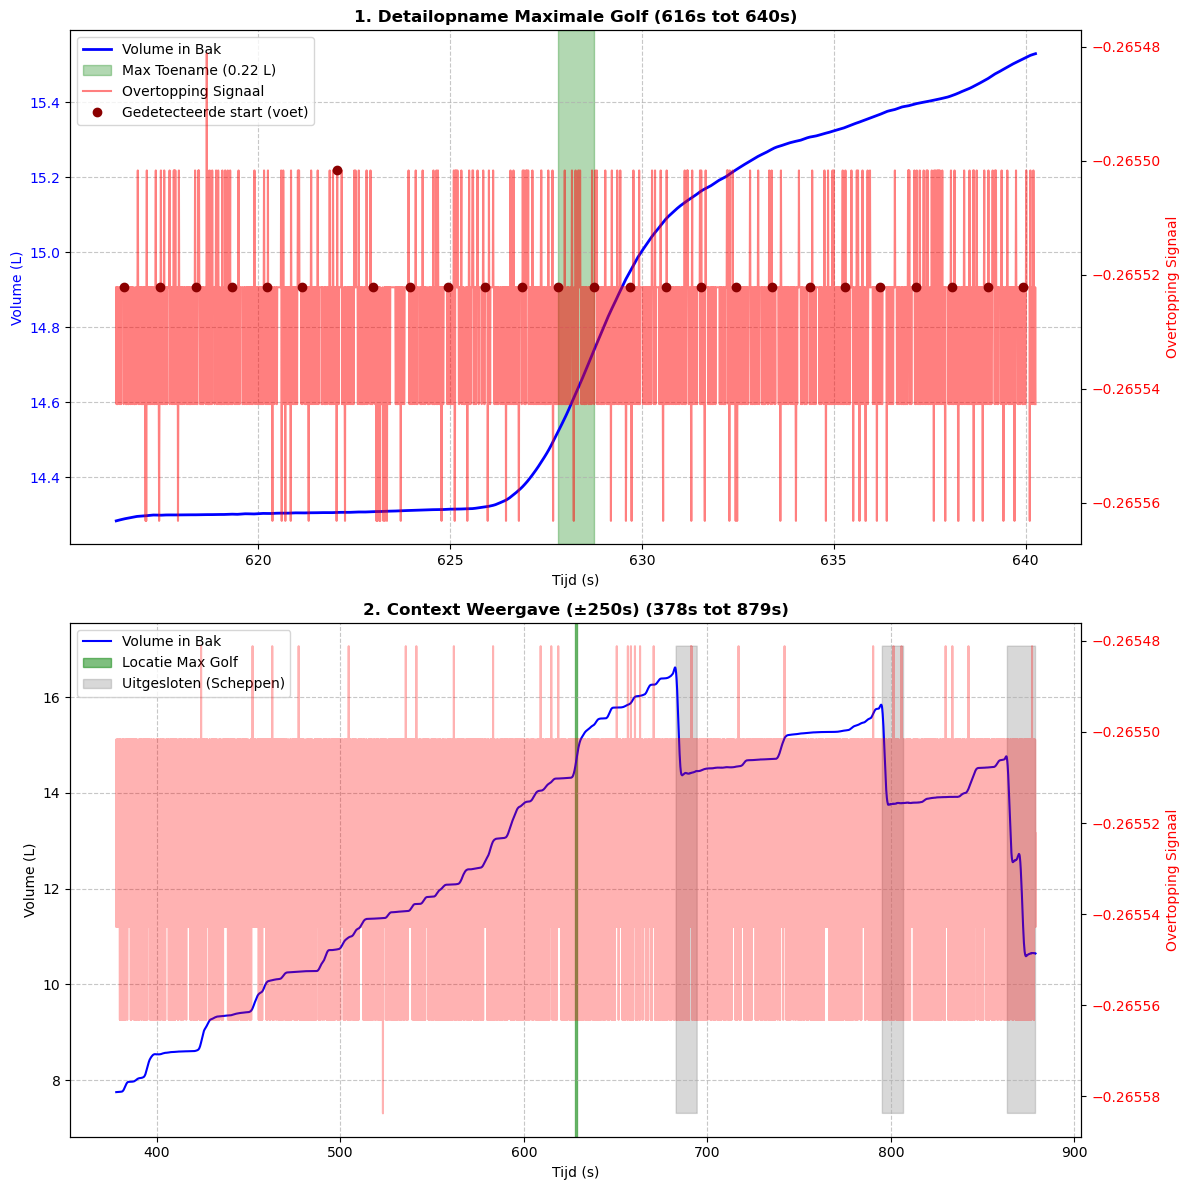

In [187]:
import numpy as np
import matplotlib.pyplot as plt

def analyseer_maximale_golf_tussen_starts(df, T_golf, fs=128, uitsluit_tijd_s=8.0):
    """
    Berekent het maximale overtopping volume van 1 golf door te kijken naar
    de volumetoename vanaf de absolute voet van het signaal tot het volgende signaal.
    - Bovenste plot: Extreem ingezoomd op de golf zelf (± 5 Tp).
    - Onderste plot: Context weergave (± 250s rondom de klap).
    """
    window_tp = int(T_golf * fs)
    window_uitsluit = int(uitsluit_tijd_s * fs)
    
    # ---------------------------------------------------------
    # CONSTRAINT: Uitsluiten van leegloop/pomp-nasleep
    # ---------------------------------------------------------
    if 'dV' not in df.columns:
        df['dV'] = df['Volume_pomp_smooth'].diff(fs).fillna(0)
        
    is_dropping = df['dV'] < -0.1
    recent_gepompt = is_dropping.rolling(window=window_uitsluit, min_periods=1).max().astype(bool)
    
    # ---------------------------------------------------------
    # DETECTIE: "Start" van het signaal (Aan de absolute voet)
    # ---------------------------------------------------------
    # We bepalen de strakke horizontale 'nullijn' (het 5e percentiel filtert ruis eruit)
    nullijn = np.percentile(df['Signaal'], 5)
    
    # We berekenen de maximale hoogte van de pieken
    amplitude = df['Signaal'].max() - nullijn
    
    # Drempel: zodra het signaal 2% van de maximale hoogte bereikt, is het een 'start'
    drempel = nullijn + 0.02 * amplitude 
    
    is_high = df['Signaal'] > drempel
    starts_ruw = np.where(is_high & ~is_high.shift(1, fill_value=False))[0]
    
    # Filter starts die te dicht op elkaar zitten (binnen 0.4x T_golf)
    min_afstand = int(0.4 * window_tp)
    starts_gefilterd = []
    for s in starts_ruw:
        if not starts_gefilterd or s - starts_gefilterd[-1] >= min_afstand:
            starts_gefilterd.append(s)
            
    geldige_starts = [idx for idx in starts_gefilterd if not recent_gepompt.iloc[idx]]
    
    if len(geldige_starts) < 2:
        print("Niet genoeg signalen gevonden om een interval te meten.\n")
        return 0
        
    # ---------------------------------------------------------
    # BEREKENING: Volume tussen 2 aansluitende starts
    # ---------------------------------------------------------
    max_vol = 0
    beste_start_idx = 0
    beste_eind_idx = 0
    aantal_geldige_intervallen = 0
    
    for i in range(len(geldige_starts) - 1):
        idx_huidig = geldige_starts[i]
        idx_volgend = geldige_starts[i+1]
        
        # Sla over als er geschept is tijdens dit interval
        if recent_gepompt.iloc[idx_huidig:idx_volgend].any():
            continue
            
        vol_start = df['Volume_pomp_smooth'].iloc[idx_huidig]
        vol_eind = df['Volume_pomp_smooth'].iloc[idx_volgend]
        
        toename = vol_eind - vol_start
        aantal_geldige_intervallen += 1
        
        if toename > max_vol:
            max_vol = toename
            beste_start_idx = idx_huidig
            beste_eind_idx = idx_volgend

    print("--- RESULTATEN TUSSEN SIGNAAL-STARTS ---")
    print(f"Aantal geanalyseerde golf-intervallen: {aantal_geldige_intervallen}")
    
    if max_vol > 0:
        tijd_start = df['Tijd'].iloc[beste_start_idx]
        tijd_eind = df['Tijd'].iloc[beste_eind_idx]
        print(f"Maximale toename tussen de voet van golf A en B = {max_vol:.2f} Liter")
        print(f"Dit gebeurde tussen t = {tijd_start:.1f}s en t = {tijd_eind:.1f}s.\n")
    else:
        print("Geen volumestijgingen gevonden.\n")
        return 0

    # ---------------------------------------------------------
    # VISUALISATIE (Boven = Extreem Ingezoomd, Onder = ±250s Context)
    # ---------------------------------------------------------
    fig, (ax_in, ax_uit) = plt.subplots(2, 1, figsize=(12, 12))
    
    t_start_vlak = df['Tijd'].iloc[beste_start_idx]
    t_eind_vlak = df['Tijd'].iloc[beste_eind_idx]
    
    # -------------------------------------------------------------------
    # --- PANEEL 1 (BOVEN): EXTREEM INGEZOOMD OP DE KLAP (± 5 Tp)     ---
    # -------------------------------------------------------------------
    zoom_klap_s = 5 * T_golf  # 5 golfperiodes ruimte voor en na
    zoom_start_in = max(0, beste_start_idx - int(zoom_klap_s * fs))
    zoom_eind_in = min(len(df)-1, beste_eind_idx + int(zoom_klap_s * fs))
    
    t_zoom_in = df['Tijd'].iloc[zoom_start_in:zoom_eind_in]
    v_zoom_in = df['Volume_pomp_smooth'].iloc[zoom_start_in:zoom_eind_in]
    sig_zoom_in = df['Signaal'].iloc[zoom_start_in:zoom_eind_in]
    recent_gepompt_zoom_in = recent_gepompt.iloc[zoom_start_in:zoom_eind_in]
    
    ax_in.plot(t_zoom_in, v_zoom_in, label='Volume in Bak', color='blue', linewidth=2)
    ax_in.axvspan(t_start_vlak, t_eind_vlak, color='green', alpha=0.3, label=f'Max Toename ({max_vol:.2f} L)')
    ax_in.fill_between(t_zoom_in, ax_in.get_ylim()[0], ax_in.get_ylim()[1], 
                     where=recent_gepompt_zoom_in, color='gray', alpha=0.2)
    
    t_min_plot = df['Tijd'].iloc[zoom_start_in]
    t_max_plot = df['Tijd'].iloc[zoom_eind_in]
    ax_in.set_title(f"1. Detailopname Maximale Golf ({t_min_plot:.0f}s tot {t_max_plot:.0f}s)", fontweight='bold')
    ax_in.set_xlabel('Tijd (s)')
    ax_in.set_ylabel('Volume (L)', color='blue')
    ax_in.tick_params(axis='y', labelcolor='blue')
    ax_in.grid(True, linestyle='--', alpha=0.7)
    
    ax2_in = ax_in.twinx()
    ax2_in.plot(t_zoom_in, sig_zoom_in, color='red', alpha=0.5, label='Overtopping Signaal')
    
    # Rode stippen op de WARE start (voet) van het signaal
    starts_in_zoom_in = [p for p in geldige_starts if zoom_start_in <= p <= zoom_eind_in]
    ax2_in.plot(df['Tijd'].iloc[starts_in_zoom_in], df['Signaal'].iloc[starts_in_zoom_in], 
             "o", color='darkred', markersize=6, label='Gedetecteerde start (voet)')
             
    ax2_in.set_ylabel('Overtopping Signaal', color='red')
    ax2_in.tick_params(axis='y', labelcolor='red')
    
    lines_1, labels_1 = ax_in.get_legend_handles_labels()
    lines_2, labels_2 = ax2_in.get_legend_handles_labels()
    by_label = dict(zip(labels_1 + labels_2, lines_1 + lines_2))
    ax_in.legend(by_label.values(), by_label.keys(), loc='upper left')

    # -------------------------------------------------------------------
    # --- PANEEL 2 (ONDER): CONTEXT (± 250s rondom de klap)           ---
    # -------------------------------------------------------------------
    zoom_context_s = 250.0
    zoom_start_uit = max(0, beste_start_idx - int(zoom_context_s * fs))
    zoom_eind_uit = min(len(df)-1, beste_eind_idx + int(zoom_context_s * fs))
    
    t_zoom_uit = df['Tijd'].iloc[zoom_start_uit:zoom_eind_uit]
    v_zoom_uit = df['Volume_pomp_smooth'].iloc[zoom_start_uit:zoom_eind_uit]
    sig_zoom_uit = df['Signaal'].iloc[zoom_start_uit:zoom_eind_uit]
    recent_gepompt_zoom_uit = recent_gepompt.iloc[zoom_start_uit:zoom_eind_uit]

    ax_uit.plot(t_zoom_uit, v_zoom_uit, color='blue', linewidth=1.5, label='Volume in Bak')
    ax_uit.axvspan(t_start_vlak, t_eind_vlak, color='green', alpha=0.5, label=f'Locatie Max Golf')
    ax_uit.fill_between(t_zoom_uit, ax_uit.get_ylim()[0], ax_uit.get_ylim()[1], 
                     where=recent_gepompt_zoom_uit, color='gray', alpha=0.3, label='Uitgesloten (Scheppen)')
    
    t_min_plot_uit = df['Tijd'].iloc[zoom_start_uit]
    t_max_plot_uit = df['Tijd'].iloc[zoom_eind_uit]
    ax_uit.set_title(f"2. Context Weergave (±250s) ({t_min_plot_uit:.0f}s tot {t_max_plot_uit:.0f}s)", fontweight='bold')
    ax_uit.set_xlabel('Tijd (s)')
    ax_uit.set_ylabel('Volume (L)')
    ax_uit.grid(True, linestyle='--', alpha=0.7)
    
    # Signaal ook toevoegen in de context-plot voor beter overzicht
    ax2_uit = ax_uit.twinx()
    ax2_uit.plot(t_zoom_uit, sig_zoom_uit, color='red', alpha=0.3)
    ax2_uit.set_ylabel('Overtopping Signaal', color='red')
    ax2_uit.tick_params(axis='y', labelcolor='red')

    # Legende voor paneel 2
    lines_uit, labels_uit = ax_uit.get_legend_handles_labels()
    ax_uit.legend(lines_uit, labels_uit, loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    return max_vol

max_volume_van_1_golf = analyseer_maximale_golf_tussen_starts(
    df_result, 
    T_golf=2.3, 
    fs=128, 
    uitsluit_tijd_s=8.0
)

De berekende golflengte is 3.08 meter.
